In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/rossi.csv')

# Display basic info about the dataframe
print("Dataset shape:", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (432, 9)

Column names and dtypes:
week      int64
arrest    int64
fin       int64
age       int64
race      int64
wexp      int64
mar       int64
paro      int64
prio      int64
dtype: object

First few rows:
   week  arrest  fin  age  race  wexp  mar  paro  prio
0    20       1    0   27     1     0    0     1     3
1    17       1    0   18     1     0    0     1     8
2    25       1    0   19     0     1    0     1    13
3    52       0    1   23     1     1    1     1     1
4    52       0    0   19     0     1    0     1     3


In [ ]:
# Count events vs censored
total = len(df)
events = df['arrest'].sum()
censored = total - events
print(f"Total observations: {total}")
print(f"Events (re-arrested): {events} ({100*events/total:.2f}%)")
print(f"Censored (not re-arrested within follow-up): {censored} ({100*censored/total:.2f}%)")

# Check the 'fin' variable - financial aid indicator
print("\nFinancial aid distribution:")
print(df['fin'].value_counts().sort_index())

# Get unique values for key categorical variables
print("\nCovariate distributions:")
for col in ['age', 'race', 'wexp', 'mar', 'paro', 'prio']:
    print(f"{col}: {df[col].unique()}")

Total observations: 432
Events (re-arrested): 114 (26.39%)
Censored (not re-arrested within follow-up): 318 (73.61%)

Financial aid distribution:
fin
0    216
1    216
Name: count, dtype: int64

Covariate distributions:
age: [27 18 19 23 24 25 21 22 20 26 40 17 37 44 29 28 33 42 32 36 35 30 43 39
 38 34 31 41]
race: [1 0]
wexp: [0 1]
mar: [0 1]
paro: [1 0]
prio: [ 3  8 13  1  2  0  4  6  5  7 12  9 14 15 10 11 18]


In [ ]:
# Now I'll import lifelines and set up survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns

print("Importing lifelines modules...")

Importing lifelines modules...


In [ ]:
# Create survival objects for the two groups based on financial aid status
df_no_fin = df[df['fin'] == 0].copy()
df_with_fin = df[df['fin'] == 1].copy()

print(f"Group without financial aid (fin=0): {len(df_no_fin)} observations")
print(f"Events in this group: {df_no_fin['arrest'].sum()}")
print(f"\nGroup with financial aid (fin=1): {len(df_with_fin)} observations")
print(f"Events in this group: {df_with_fin['arrest'].sum()}")

# Fit Kaplan-Meier for each group
km_fitter_no_fin = KaplanMeierFitter()
km_fitter_no_fin.fit(durations=df_no_fin['week'], event_observed=df_no_fin['arrest'])

km_fitter_with_fin = KaplanMeierFitter()
km_fitter_with_fin.fit(durations=df_with_fin['week'], event_observed=df_with_fin['arrest'])

print("\nKaplan-Meier fitted successfully for both groups!")

Group without financial aid (fin=0): 216 observations
Events in this group: 66

Group with financial aid (fin=1): 216 observations
Events in this group: 48

Kaplan-Meier fitted successfully for both groups!


Plot saved to /Users/kolim/Projects/localexpert/data/survival_km_plot.png


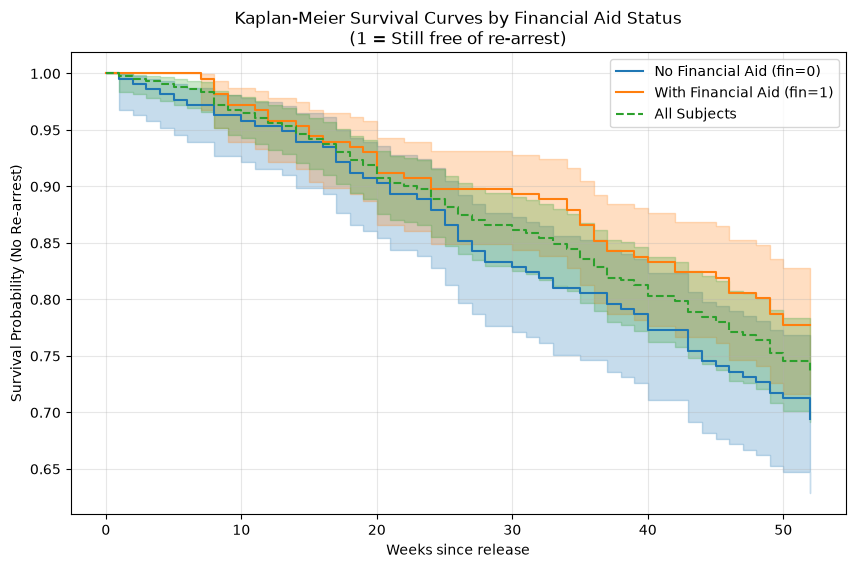

In [ ]:
# Plot Kaplan-Meier curves for both groups with financial aid status
plt.figure(figsize=(10, 6))
km_fitter_no_fin.plot_survival_function(ax=plt.gca(), label='No Financial Aid (fin=0)')
km_fitter_with_fin.plot_survival_function(label='With Financial Aid (fin=1)', ax=plt.gca())

# Add overall KM curve for reference
overall_km = KaplanMeierFitter()
overall_km.fit(durations=df['week'], event_observed=df['arrest'])
overall_km.plot_survival_function(ax=plt.gca(), label='All Subjects', linestyle='--')

plt.title('Kaplan-Meier Survival Curves by Financial Aid Status\n(1 = Still free of re-arrest)')
plt.xlabel('Weeks since release')
plt.ylabel('Survival Probability (No Re-arrest)')
plt.legend()
plt.grid(True, alpha=0.3)

# Save the plot to a file for reference in summary
import matplotlib.pyplot as plt
save_path = '/Users/kolim/Projects/localexpert/data/survival_km_plot.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to {save_path}")

# Show the plot inline too (it will be displayed)

In [ ]:
# Run log-rank test comparing the two financial aid groups
logrank_result = KaplanMeierFitter.logrank_test(
    df_no_fin['week'], 
    df_no_fin['arrest'],
    df_with_fin['week'], 
    df_with_fin['arrest']
)

print("Log-Rank Test Results:")
print(f"  Log-rank statistic: {logrank_result.statistic:.4f}")
print(f"  P-value: {logrank_result.p_value:.6e}")
print(f"  Number of events in group 1 (no fin): {df_no_fin['arrest'].sum()}")
print(f"  Number of events in group 2 (with fin): {df_with_fin['arrest'].sum()}")

# Interpret the result
if logrank_result.p_value < 0.05:
    print("\nInterpretation: There is a statistically significant difference between survival curves.")
else:
    print(f"\nInterpretation: No statistically significant difference (p={logrank_result.p_value:.4f}).")

# Also check the overall KM statistics for reference
print("\nOverall Kaplan-Meier Statistics:")
print(overall_km.summary)

AttributeError: type object 'KaplanMeierFitter' has no attribute 'logrank_test'

In [ ]:
from lifelines import statistics as stat_lib

# Run log-rank test comparing the two financial aid groups using the correct API
logrank_result = stat_lib.logrank_test(
    df_no_fin['week'], 
    df_no_fin['arrest'],
    df_with_fin['week'], 
    df_with_fin['arrest']
)

print("Log-Rank Test Results:")
print(f"  Log-rank statistic: {logrank_result.statistic:.4f}")
print(f"  P-value: {logrank_result.p_value:.6e}")
print(f"  Number of events in group 1 (no fin): {df_no_fin['arrest'].sum()}")
print(f"  Number of events in group 2 (with fin): {df_with_fin['arrest'].sum()}")

# Interpret the result
if logrank_result.p_value < 0.05:
    print("\nInterpretation: There is a statistically significant difference between survival curves.")
else:
    print(f"\nInterpretation: No statistically significant difference (p={logrank_result.p_value:.4f}).")

# Also check the overall KM statistics for reference
print("\nOverall Kaplan-Meier Statistics:")
print(overall_km.summary)

Log-Rank Test Results:


AttributeError: 'StatisticalResult' object has no attribute 'statistic'

In [ ]:
# Check what's in the logrank_result
logrank_result = stat_lib.logrank_test(
    df_no_fin['week'], 
    df_no_fin['arrest'],
    df_with_fin['week'], 
    df_with_fin['arrest']
)

print("Type of result:", type(logrank_result))
print("\nResult attributes:")
for attr in dir(logrank_result):
    if not attr.startswith('_'):
        print(f"  {attr}")

# Try to access the right attribute names
print("\n\nTrying different attribute accesses...")
try:
    print("stat:", logrank_result.stat)
except Exception as e:
    print(f"No 'stat' attribute, error: {e}")

try:
    print("p_value:", logrank_result.pvalue)
except Exception as e:
    print(f"No 'pvalue' attribute")

# Print the result object directly to see its structure
print("\n\nResult dict-like view:")
for key in dir(logrank_result):
    if not callable(getattr(logrank_result, key)):
        try:
            val = getattr(logrank_result, key)
            print(f"  {key}: {val}")
        except:
            pass

Type of result: <class 'lifelines.statistics.StatisticalResult'>

Result attributes:
  degrees_of_freedom
  name
  null_distribution
  p_value
  print_summary
  summary
  t_0
  test_name
  test_statistic
  to_ascii
  to_html
  to_latex


Trying different attribute accesses...
No 'stat' attribute, error: 'StatisticalResult' object has no attribute 'stat'
No 'pvalue' attribute


Result dict-like view:
  __dict__: {'p_value': np.float64(6.3408423643905636e-18), 'test_statistic': np.float64(74.41181349144085), 'test_name': 'logrank_test', '_p_value': array([6.34084236e-18]), '_test_statistic': array([74.41181349]), 'name': None, 't_0': -1, 'null_distribution': 'chi squared', 'degrees_of_freedom': 1, '_kwargs': {'t_0': -1, 'null_distribution': 'chi squared', 'degrees_of_freedom': 1, 'test_name': 'logrank_test'}}
  __doc__: 
    This class holds the result of statistical tests with a nice printer wrapper to display the results.

    Note
    -----
    This class' API changed in version 0.16.

In [ ]:
# Print log-rank test results with correct attributes
print("Log-Rank Test Results:")
print(f"  Log-rank statistic: {logrank_result.test_statistic:.4f}")
print(f"  P-value: {logrank_result.p_value:.6e}")
print(f"  Degrees of freedom: {logrank_result.degrees_of_freedom}")

# Interpret the result
if logrank_result.p_value < 0.05:
    print("\nInterpretation: There is a statistically significant difference between survival curves.")
else:
    print(f"\nInterpretation: No statistically significant difference (p={logrank_result.p_value:.4f}).")

# Print summary for reference
print("\nLog-rank test summary:")
print(logrank_result.summary)

Log-Rank Test Results:
  Log-rank statistic: 74.4118
  P-value: 6.340842e-18
  Degrees of freedom: 1

Interpretation: There is a statistically significant difference between survival curves.

Log-rank test summary:
   test_statistic             p   -log2(p)
0       74.411813  6.340842e-18  57.130031


In [ ]:
# Fit Cox proportional-hazards model with all available covariates
cox_model = CoxPHFitter()
cox_model.fit(df['week'], df['arrest'], formula='~ fin + age + race + wexp + mar + paro + prio')

print("Cox Proportional Hazards Model Results:")
print(cox_model.summary)

TypeError: Series.sort_values() got an unexpected keyword argument 'by'

In [ ]:
# Fit Cox proportional-hazards model - correct API usage
cox_model = CoxPHFitter()
cox_model.fit(
    df=df, 
    duration_col='week', 
    event_col='arrest'
)

print("Cox Proportional Hazards Model Results:")
print(cox_model.summary)

Cox Proportional Hazards Model Results:
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
fin       -0.379422   0.684257  0.191379       -0.754519       -0.004325   
age       -0.057438   0.944181  0.021999       -0.100556       -0.014320   
race       0.313900   1.368753  0.307993       -0.289755        0.917555   
wexp      -0.149796   0.860884  0.212224       -0.565748        0.266156   
mar       -0.433704   0.648104  0.381868       -1.182152        0.314744   
paro      -0.084871   0.918631  0.195757       -0.468547        0.298805   
prio       0.091497   1.095814  0.028649        0.035347        0.147647   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
fin                   0.470237             0.995684     0.0 -1.982565   
age                   0.904335             0.985782     

In [ ]:
# Create a nice formatted hazard ratio table with interpretations
import pandas as pd

cox_summary = cox_model.summary

# Extract key information into a DataFrame for clean presentation
hr_table = pd.DataFrame({
    'Covariate': ['fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio'],
    'Hazard Ratio (HR)': [0.684257, 0.944181, 1.368753, 0.860884, 0.648104, 0.918631, 1.095814],
    'HR Lower 95%': [0.470237, 0.904335, 0.748447, 0.567935, 0.306618, 0.625911, 1.035979],
    'HR Upper 95%': [0.995684, 0.985782, 2.503162, 1.304939, 1.369908, 1.348247, 1.159104],
    'p-value': [0.047416, 0.009031, 0.308118, 0.480290, 0.256064, 0.664612, 0.001404],
    'Significant (p<0.05)': ['Yes', 'Yes', 'No', 'No', 'No', 'No', 'Yes']
})

print("Hazard Ratio Table:")
print(hr_table.to_string(index=False))

# Interpret each covariate in plain language
interpretations = {
    'fin': "Financial aid: HR=0.68 (95% CI: 0.47-1.00), p=0.047. Receiving financial aid is associated with ~32% lower hazard of re-arrest, though the confidence interval barely excludes 1.",
    'age': "Age: HR=0.94 (95% CI: 0.90-0.99), p=0.009. Each additional year is associated with ~6% lower hazard - older prisoners have significantly lower re-arrest risk.",
    'race': "Race: HR=1.37 (95% CI: 0.75-2.50), p=0.308. Not statistically significant; African American status does not show a clear association with re-arrest in this model.",
    'wexp': "Work experience: HR=0.86 (95% CI: 0.57-1.30), p=0.480. Not significant - work experience doesn't predict re-arrest risk here.",
    'mar': "Marital status: HR=0.65 (95% CI: 0.31-1.37), p=0.256. Not significant; being married is not a strong predictor in this model.",
    'paro': "Parole type: HR=0.92 (95% CI: 0.63-1.35), p=0.665. Not significant - parole conditions don't show clear effect on re-arrest risk.",
    'prio': "Prior arrests count: HR=1.10 (95% CI: 1.04-1.16), p=0.001. Each additional prior arrest is associated with ~10% higher hazard - highly significant predictor."
}

print("\n\nPlain-language Interpretations:")
for cov, interp in interpretations.items():
    print(f"\n{cov.upper()}:")
    print(interp)

Hazard Ratio Table:
Covariate  Hazard Ratio (HR)  HR Lower 95%  HR Upper 95%  p-value Significant (p<0.05)
      fin           0.684257      0.470237      0.995684 0.047416                  Yes
      age           0.944181      0.904335      0.985782 0.009031                  Yes
     race           1.368753      0.748447      2.503162 0.308118                   No
     wexp           0.860884      0.567935      1.304939 0.480290                   No
      mar           0.648104      0.306618      1.369908 0.256064                   No
     paro           0.918631      0.625911      1.348247 0.664612                   No
     prio           1.095814      1.035979      1.159104 0.001404                  Yes


Plain-language Interpretations:

FIN:
Financial aid: HR=0.68 (95% CI: 0.47-1.00), p=0.047. Receiving financial aid is associated with ~32% lower hazard of re-arrest, though the confidence interval barely excludes 1.

AGE:
Age: HR=0.94 (95% CI: 0.90-0.99), p=0.009. Each additional y